# 02_Exploratory_Data_Analysis

## Objective

The objective of this notebook is to explore customer purchasing behavior and overall business performance within the Olist e-commerce dataset.

This notebook will:

- Examine order trends over time
- Analyze revenue patterns
- Evaluate customer purchasing behavior
- Identify top-performing product categories
- Generate business insights that can support decision-making

The findings from this analysis will provide a foundation for customer segmentation, retention analysis, and customer lifetime value modeling.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

## Step 1: Load Required Tables

In [4]:
customers = pd.read_csv("../data/olist_customers_dataset.csv")

orders = pd.read_csv(
    "../data/olist_orders_dataset.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
)

order_items = pd.read_csv("../data/olist_order_items_dataset.csv")

payments = pd.read_csv("../data/olist_order_payments_dataset.csv")

products = pd.read_csv("../data/olist_products_dataset.csv")

### First Business Question

How many orders are actually valid completed purchases?

In [6]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

### Create Analysis Dataset

In [8]:
delivered_orders = orders[
    orders["order_status"] == "delivered"
].copy()

print(f"Delivered Orders: {len(delivered_orders):,}")

Delivered Orders: 96,478


## Selection of Completed Orders

### Results

- Total Orders: 99,441
- Delivered Orders: 96,478

### Findings

- Approximately 97% of all orders were successfully delivered.
- A small number of orders were canceled, unavailable, or still in progress.

### Business Decision

Only delivered orders will be used for customer and revenue analyses throughout this project. This ensures that all metrics are based on completed transactions rather than orders that were canceled or not fulfilled.

### Key Insight

The high delivery rate allows the analysis to focus on completed purchases while excluding transactions that did not generate business value.

## Step 2: Build a Master Analysis Dataset

In [11]:
order_revenue = (
    order_items
    .groupby("order_id", as_index=False)["price"]
    .sum()
    .rename(columns={"price": "order_value"})
)

order_revenue.head()

,order_id,order_value
0,00010242fe8c5a6d1ba2dd792cb16214,58.90
1,00018f77f2f0320c557190d7a144bdd3,239.90
2,000229ec398224ef6ca0657da4fc703e,199.00
3,00024acbcdf0a6daa1e931b038114c75,12.99
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90


## Order Revenue Calculation

### Results

- Order-level revenue was calculated by summing product prices within each order.
- A new table was created containing one record per order and its corresponding order value.

### Findings

- Orders can contain multiple products.
- Revenue must therefore be aggregated at the order level before performing business analysis.

### Key Insight

Creating an order-level revenue table simplifies downstream analyses by providing a single revenue value for each completed order.

## Next Step: Attach Revenue to Delivered Orders

In [14]:
delivered_orders = delivered_orders.merge(
    order_revenue,
    on="order_id",
    how="left"
)

delivered_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,29.99
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,118.70
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,159.90
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,45.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,19.90


## Creation of Analysis Dataset

### Results

- Order-level revenue was merged with delivered orders.
- Each record now contains order information, customer information, dates, and order value.

### Findings

- The merged dataset provides a complete view of completed transactions.
- Revenue information is now available for every delivered order.

### Key Insight

The resulting dataset serves as the primary analysis table for exploring customer behavior, revenue trends, and business performance.

# Section 1: Executive KPIs
## 1.) First Business KPI: Total Revenue

In [17]:
total_revenue = delivered_orders["order_value"].sum()
print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $13,221,498.11




### Results

- Total Revenue: $13,221,498.11

### Findings

- Completed orders generated over $13.2 million in revenue.
- Revenue was calculated by summing the value of all delivered orders.

### Key Insight

The dataset represents a substantial volume of e-commerce activity, providing a strong foundation for analyzing customer purchasing behavior and business performance.

## 2.) Next KPI: Average Order Value (AOV)

In [20]:
average_order_value = delivered_orders["order_value"].mean()

print(f"Average Order Value: ${average_order_value:.2f}")

Average Order Value: $137.04


## Average Order Value (AOV)

### Results

- Average Order Value: $137.04

### Findings

- Customers spent an average of $137.04 per completed order.
- This metric provides insight into the typical transaction size within the marketplace.

### Key Insight

Average Order Value serves as a key indicator of customer spending behavior and will be useful for evaluating customer segments and revenue performance throughout the analysis.

## 3.) Next set of KPIs: Total Orders and Total Customers

In [23]:
total_orders = delivered_orders["order_id"].nunique()

total_customers = customers["customer_unique_id"].nunique()

print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")

Total Orders: 96,478
Total Customers: 96,096


## Executive KPI Summary

### Results

| KPI | Value |
|------|------:|
| Total Revenue | 13,221,498.11 |
| Average Order Value | 137.04 |
| Total Orders | 96,478 |
| Total Customers | 96,096 |

### Findings

- The marketplace generated over 13.2 million in revenue.
- The average order value was 137.04.
- A total of 96,478 completed orders were recorded.
- The customer base consisted of 96,096 unique customers.

### Key Insight

The close relationship between total orders and total customers suggests that most customers made a single purchase, highlighting the importance of customer retention and repeat purchasing behavior.

# Section 2: Time-Series Analysis
## 1.) Orders Over Time
## Step 1: Create Monthly Order Trends

In [26]:
monthly_orders = (
    delivered_orders
    .set_index("order_purchase_timestamp")
    .resample("M")["order_id"]
    .count()
)

monthly_orders.head()

C:\Users\chide\AppData\Local\Temp\ipykernel_44252\2371579267.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["order_id"]


order_purchase_timestamp
2016-09-30      1
2016-10-31    265
2016-11-30      0
2016-12-31      1
2017-01-31    750
Freq: ME, Name: order_id, dtype: int64

## Monthly Order Trend Preparation

### Results

- Orders were aggregated at the monthly level using the order purchase date.
- The resulting time series shows the number of completed orders per month.

### Findings

- Order activity was very low during the initial months of the dataset.
- Order volume increased noticeably by early 2017.
- Further analysis is required to understand the overall trend.

### Key Insight

Aggregating orders by month provides a foundation for identifying growth patterns, seasonality, and changes in customer demand over time.

### Create Visualization for Monthly Orders Over Time

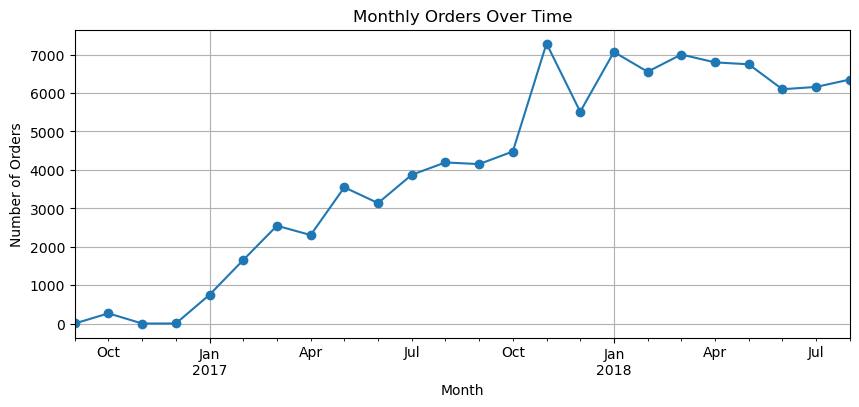

In [29]:
plt.figure(figsize=(10,4))

monthly_orders.plot(marker="o")

plt.title("Monthly Orders Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.grid(True)

plt.show()

## Monthly Order Trends

### Results

- Monthly order volume increased substantially from early 2017 to late 2017.
- Peak order activity occurred around November 2017.
- Order volume remained consistently high throughout 2018.

### Findings

- The business experienced strong growth during the observed period.
- A notable spike in orders occurred during late 2017.
- Following this growth phase, order volume stabilized at approximately 6,000–7,000 orders per month.

### Key Insight

The marketplace demonstrates rapid growth followed by a period of stable demand, suggesting successful customer acquisition and business expansion during the dataset period.

## 2.) Next Analysis: Monthly Revenue

In [32]:
monthly_revenue = (
    delivered_orders
    .set_index("order_purchase_timestamp")
    .resample("M")["order_value"]
    .sum()
)

monthly_revenue.head()

C:\Users\chide\AppData\Local\Temp\ipykernel_44252\492267857.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["order_value"]


order_purchase_timestamp
2016-09-30       134.97
2016-10-31     40325.11
2016-11-30         0.00
2016-12-31        10.90
2017-01-31    111798.36
Freq: ME, Name: order_value, dtype: float64

## Monthly Revenue Trend Preparation

### Results

- Revenue was aggregated at the monthly level using delivered orders.
- Monthly revenue values were calculated by summing order values within each month.

### Findings

- Revenue was minimal during the initial months of the dataset.
- Monthly revenue increased substantially by early 2017.
- Further visualization is required to evaluate long-term revenue growth patterns.

### Key Insight

Monthly revenue provides a direct measure of business performance and will be used to assess growth trends over time.

### Next Step: Visualize Monthly Revenue

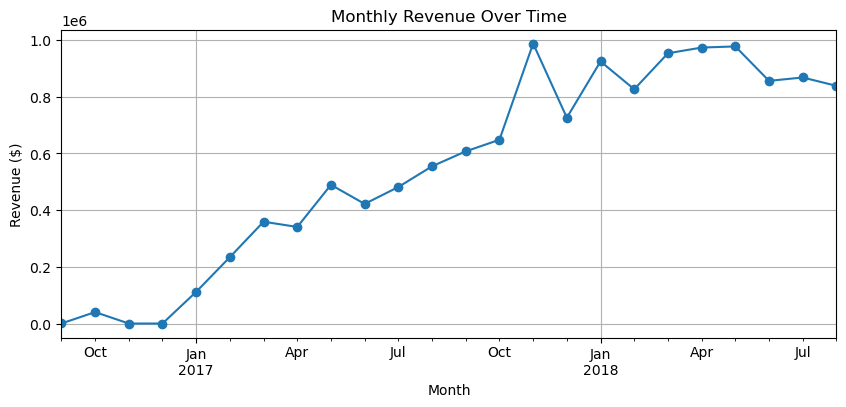

In [35]:
plt.figure(figsize=(10,4))

monthly_revenue.plot(marker="o")

plt.title("Monthly Revenue Over Time")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")

plt.grid(True)

plt.show()

## Monthly Revenue Trends

### Results

- Monthly revenue increased substantially from early 2017 through late 2017.
- Peak revenue occurred around November 2017.
- Revenue remained relatively stable throughout 2018, generally ranging between $800,000 and $1,000,000 per month.

### Findings

- Revenue growth closely mirrors the growth observed in monthly order volume.
- A significant revenue spike occurred during late 2017.
- Revenue stabilized after a period of rapid business expansion.

### Key Insight

The marketplace experienced strong revenue growth during the observation period, with evidence suggesting that increasing order volume was a major driver of business performance.

## 3.) Next Analysis: Average Order Value (AOV) Over Time

In [38]:
monthly_aov = (
    delivered_orders
    .set_index("order_purchase_timestamp")
    .resample("M")["order_value"]
    .mean()
)

monthly_aov.head()

C:\Users\chide\AppData\Local\Temp\ipykernel_44252\2172635297.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["order_value"]


order_purchase_timestamp
2016-09-30    134.970000
2016-10-31    152.170226
2016-11-30           NaN
2016-12-31     10.900000
2017-01-31    149.064480
Freq: ME, Name: order_value, dtype: float64

## Monthly Average Order Value (AOV) Preparation

### Results

- Average Order Value (AOV) was calculated for each month.
- Months with no completed orders resulted in missing values.

### Findings

- Early observations suggest that customer spending per order remained relatively consistent.
- AOV values appear to be centered around the overall average order value.

### Key Insight

Analyzing AOV over time helps determine whether revenue growth is driven by increased customer spending or by higher order volume.

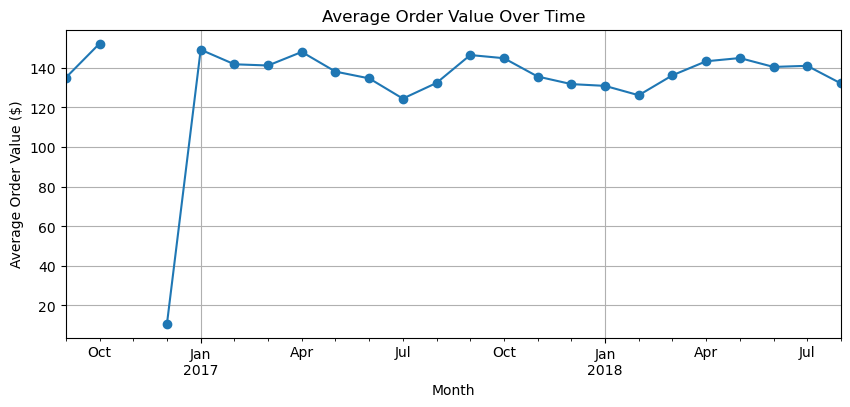

In [40]:
plt.figure(figsize=(10,4))

monthly_aov.plot(marker="o")

plt.title("Average Order Value Over Time")
plt.xlabel("Month")
plt.ylabel("Average Order Value ($)")

plt.grid(True)

plt.show()

## Average Order Value (AOV) Trends

### Results

- Monthly AOV remained relatively stable throughout the observation period.
- Most months recorded an AOV between 125 and 150.
- The overall average order value was $137.04.

### Findings

- No significant long-term upward or downward trend was observed in customer spending per order.
- Revenue growth did not coincide with major increases in AOV.
- A low AOV value observed in December 2016 is likely due to a very small number of completed orders.

### Key Insight

While both order volume and revenue increased substantially over time, average order value remained relatively stable. This suggests that business growth was primarily driven by an increase in the number of orders rather than higher customer spending per transaction.

## 4.) Daily Order Statistics

In [43]:
daily_orders = (
    delivered_orders
    .set_index("order_purchase_timestamp")
    .resample("D")["order_id"]
    .count()
)

daily_orders.describe()

count     714.000000
mean      135.123249
std        99.562727
min         0.000000
25%        66.000000
50%       130.500000
75%       198.000000
max      1147.000000
Name: order_id, dtype: float64

## Daily Order Statistics

### Results

| Metric | Value |
|----------|----------:|
| Average Daily Orders | 135 |
| Median Daily Orders | 130.5 |
| Maximum Daily Orders | 1,147 |

### Findings

- The marketplace received an average of approximately 135 orders per day.
- Daily demand varied considerably throughout the observation period.
- Peak daily order volume exceeded 1,100 orders.

### Key Insight

Order activity was generally consistent on a typical day but experienced occasional demand spikes, indicating periods of increased customer purchasing activity.

# Section 3: Product Analysis
## Next Step: Create a Product Category Table

In [46]:
category_translation = pd.read_csv(
    "../data/product_category_name_translation.csv"
)

category_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [47]:
products_with_categories = products.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

products_with_categories.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


## Product Category Translation

### Results

- Product category translations were merged with the Products table.
- Portuguese category names were converted to English equivalents.

### Findings

- Category names are now easier to interpret and communicate.
- The translated categories will be used in all subsequent product analyses.

### Key Insight

Translating category names improves the readability of visualizations and business insights, making the analysis more accessible to stakeholders.

## Next Step: Build the Product Sales Dataset

In [50]:
product_sales = order_items.merge(
    products_with_categories[
    ["product_id", "product_category_name_english"]
    ],
    on= "product_id",
    how="left"
)

product_sales.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,garden_tools


## Next Step: Calculate Revenue by Product Category

In [52]:
category_revenue = (
    product_sales
    .groupby("product_category_name_english", as_index=False)["price"]
    .sum()
    .sort_values("price", ascending=False)
)

category_revenue.head(10)

,product_category_name_english,price
43,health_beauty,1258681.34
70,watches_gifts,1205005.68
7,bed_bath_table,1036988.68
65,sports_leisure,988048.97
15,computers_accessories,911954.32
39,furniture_decor,729762.49
20,cool_stuff,635290.85
49,housewares,632248.66
5,auto,592720.11
42,garden_tools,485256.46


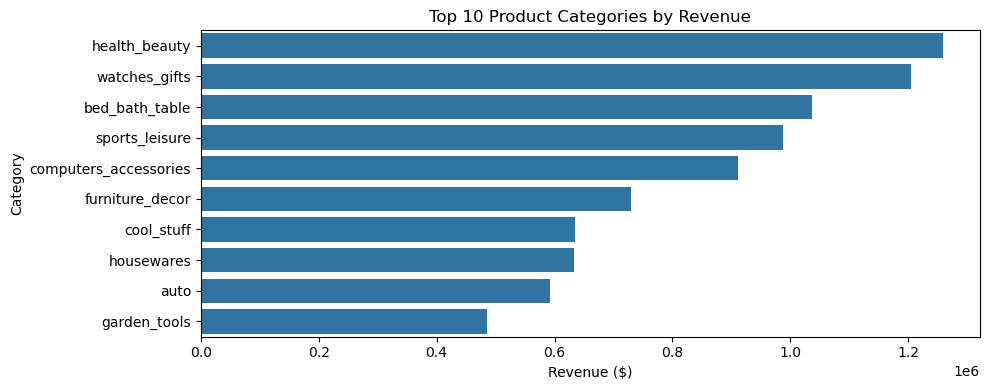

In [53]:
top10_categories = category_revenue.head(10)

plt.figure(figsize=(10,4))

sns.barplot(
    data=top10_categories,
    x="price",
    y="product_category_name_english"
)

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Revenue ($)")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

## Top Product Categories by Revenue

### Results

Top revenue-generating categories include:

1. Health & Beauty (1.26M)
2. Watches & Gifts (1.21M)
3. Bed, Bath & Table (1.04M)
4. Sports & Leisure (0.99M)
5. Computers & Accessories (0.91M)

### Findings

- Revenue is concentrated among a relatively small number of product categories.
- Lifestyle, home, and technology products generate the highest sales revenue.
- Health & Beauty is the leading revenue category.

### Key Insight

A small group of categories drives a substantial share of marketplace revenue, indicating where marketing, inventory, and growth initiatives may have the greatest impact.

## Next Analysis: Revenue Concentration

In [56]:
top10_revenue = category_revenue.head(10)["price"].sum()

total_category_revenue = category_revenue["price"].sum()

top10_percentage = (
    top10_revenue / total_category_revenue
) * 100

print(f"Top 10 Revenue Share: {top10_percentage:.2f}%")

Top 10 Revenue Share: 63.22%


## Revenue Concentration Analysis

### Results

- Top 10 Categories Revenue Share: 63.22%

### Findings

- A relatively small number of categories generate the majority of marketplace revenue.
- The top 10 categories account for nearly two-thirds of total sales revenue.

### Key Insight

Revenue is highly concentrated among a limited set of product categories. This indicates that business performance is heavily influenced by a small number of key product segments.

# Section 4: Customer Geography Analysis

In [81]:
customer_locations = customers[
    [
        "customer_id",
        "customer_unique_id",
        "customer_city",
        "customer_state"
    ]
]

customer_locations.head()

,customer_id,customer_unique_id,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,campinas,SP


## Merge the customer location data into the main analysis dataset.

In [83]:
orders_geo = delivered_orders.merge(
    customer_locations,
    on="customer_id",
    how="left"
)

orders_geo.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_value,customer_unique_id,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,29.99,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,118.70,af07308b275d755c9edb36a90c618231,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,159.90,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,45.00,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,19.90,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP


## Geographic Analysis Dataset

### Results

- Customer location information was merged with delivered order data.
- Each completed order now includes customer city and state information.

### Findings

- Order activity can now be analyzed geographically.
- Revenue, customer counts, and order volume can be evaluated by region.

### Key Insight

Combining transaction and location data enables regional performance analysis and identification of key customer markets.

## Top States by Revenue

In [90]:
state_revenue = (
    orders_geo
    .groupby("customer_state", as_index=False)["order_value"]
    .sum()
    .sort_values("order_value", ascending=False)
)

state_revenue.head(10)

,customer_state,order_value
25,SP,5067633.16
18,RJ,1759651.13
10,MG,1552481.83
22,RS,728897.47
17,PR,666063.51
23,SC,507012.13
4,BA,493584.14
6,DF,296498.41
8,GO,282836.70
7,ES,268643.45


## Next Step: Visualize the Top States

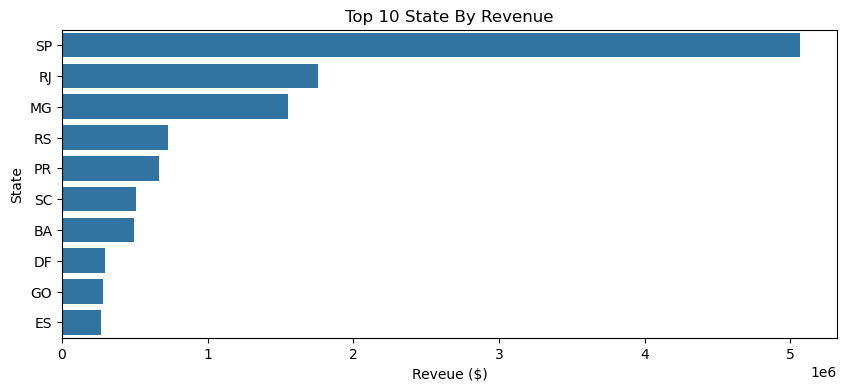

In [95]:
top10_states = state_revenue.head(10)

plt.figure(figsize=(10, 4))

sns.barplot(
    data=top10_states,
    x="order_value",
    y="customer_state"
)

plt.title("Top 10 State By Revenue")
plt.xlabel("Reveue ($)")
plt.ylabel("State")

plt.show()

## Top States by Revenue

### Results

| State | Revenue (USD) |
|---------|------------:|
| SP | 5.07M |
| RJ | 1.76M |
| MG | 1.55M |
| RS | 0.73M |
| PR | 0.67M |

### Findings

- São Paulo generated substantially more revenue than any other state.
- RJ and MG were the second and third highest revenue-generating states.
- Revenue declines sharply after the top three states, indicating geographic concentration.

### Key Insight

Revenue is heavily concentrated in a few key states, with São Paulo significantly outperforming all other regions. This suggests that marketplace growth is strongly influenced by a small number of geographic markets, particularly SP, RJ, and MG.

## Next Step: Quantify the Concentration

In [99]:
top3_revenue = state_revenue.head(3)["order_value"].sum()

total_revenue_geo = state_revenue["order_value"].sum()

top3_share = (top3_revenue / total_revenue_geo) * 100

print(f"Top 3 States Revenue Share: {top3_share:.2f}%")

Top 3 States Revenue Share: 63.38%


## Revenue Concentration by State

### Results

| Metric | Value |
|----------|----------:|
| Top 3 States Revenue Share | 63.38% |

### Findings

- The top three states (SP, RJ, and MG) generated 63.38% of total marketplace revenue.
- Revenue is concentrated among a small number of geographic regions.
- São Paulo represents the largest contributor to overall business performance.

### Key Insight

The marketplace exhibits a high degree of geographic concentration, with nearly two-thirds of total revenue originating from only three states. This indicates that business performance is strongly influenced by a limited number of key regional markets.

## Top States by Customer Count

In [103]:
state_customers = (
    orders_geo
    .groupby("customer_state")["customer_unique_id"]
    .nunique()
    .reset_index(name="unique_customers")
    .sort_values("unique_customers", ascending=False)
)

state_customers.head(10)

,customer_state,unique_customers
25,SP,39156
18,RJ,11917
10,MG,11001
22,RS,5168
17,PR,4769
23,SC,3449
4,BA,3158
6,DF,2019
7,ES,1928
8,GO,1895


## Top States by Customer Count

### Results

| State | Unique Customers |
|---------|---------------:|
| SP | 39,156 |
| RJ | 11,917 |
| MG | 11,001 |
| RS | 5,168 |
| PR | 4,769 |

### Findings

- São Paulo has the largest customer base by a substantial margin.
- RJ and MG rank second and third in customer count.
- The customer ranking closely matches the revenue ranking.

### Key Insight

States with the highest revenue also have the largest customer populations. This suggests that geographic revenue concentration is primarily driven by customer concentration rather than significantly higher spending behavior.

## Average Revenue Per Customer by State

In [111]:
state_metrics = (
    orders_geo
    .groupby("customer_state")
    .agg(
        revenue=("order_value", "sum"),
        customers=("customer_unique_id", "nunique")
    )
)

state_metrics["revenue_per_customer"] = (
    state_metrics["revenue"] /
    state_metrics["customers"]
)

state_metrics = (
    state_metrics
    .sort_values("revenue_per_customer", ascending=False)
)

state_metrics.head(10)

,revenue,customers,revenue_per_customer
customer_state,,,
PB,112586.82,504,223.386548
AC,15930.97,76,209.618026
AL,78855.72,387,203.761550
AP,13374.81,66,202.648636
RO,45682.76,231,197.760866
PA,174470.59,922,189.230575
PI,84721.00,464,182.588362
TO,48402.51,267,181.282809
MT,152191.62,856,177.793949


### Filter out small populations: A small number of customers can inflate averages.

In [115]:
state_metrics[state_metrics["customers"] >= 1000] \
    .sort_values("revenue_per_customer", ascending=False) \
    .head(10)

,revenue,customers,revenue_per_customer
customer_state,,,
CE,219757.38,1258,174.687901
PE,251889.49,1551,162.404571
BA,493584.14,3158,156.296434
GO,282836.70,1895,149.254195
RJ,1759651.13,11917,147.658902
SC,507012.13,3449,147.002647
DF,296498.41,2019,146.854091
MG,1552481.83,11001,141.121883
RS,728897.47,5168,141.040532


## Revenue per Customer by State (Customers ≥ 1,000)

### Results

| State | Revenue per Customer (USD) |
|---------|-------------------------:|
| CE | 174.69 |
| PE | 162.40 |
| BA | 156.30 |
| GO | 149.25 |
| RJ | 147.66 |

### Findings

- After filtering for states with at least 1,000 customers, CE and PE have the highest revenue per customer.
- Large revenue-generating states do not necessarily have the highest customer value.
- Revenue per customer varies considerably across regions.

### Key Insight

While SP, RJ, and MG generate the most total revenue, states such as CE and PE exhibit stronger customer spending behavior. This suggests that customer value and market size are distinct dimensions of business performance.

# Section 5: Customer Behavior Analysis

In [127]:
customer_revenue = (
    orders_geo
    .groupby("customer_unique_id", as_index=False)
    .agg(
        total_revenue=("order_value", "sum"),
        total_orders=("order_id", "nunique")
    )
)

customer_revenue.head()

,customer_unique_id,total_revenue,total_orders
0,0000366f3b9a7992bf8c76cfdf3221e2,129.90,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,18.90,1
2,0000f46a3911fa3c0805444483337064,69.00,1
3,0000f6ccb0745a6a4b88665a16c9f078,25.99,1
4,0004aac84e0df4da2b147fca70cf8255,180.00,1


## Customer-Level Dataset

### Results

- Customer-level revenue and order metrics were calculated.
- Each record represents a unique customer and summarizes their purchasing activity.

### Findings

- Total revenue was aggregated across all completed orders for each customer.
- Total order counts were calculated at the customer level.

### Key Insight

Creating a customer-level dataset enables deeper analysis of customer spending behavior, purchase frequency, and customer value.

## Next Step: Understand Customer Spending
How much does a typical customer spend?

In [131]:
customer_revenue["total_revenue"].describe()

count    93358.000000
mean       141.621480
std        215.694014
min          0.850000
25%         47.650000
50%         89.730000
75%        154.737500
max      13440.000000
Name: total_revenue, dtype: float64

## Customer Spending Distribution

### Results

| Metric | Value (USD) |
|----------|----------:|
| Average Customer Revenue | 141.62 |
| Median Customer Revenue | 89.73 |
| Maximum Customer Revenue | 13,440.00 |

### Findings

- Average customer revenue is substantially higher than the median.
- Customer spending exhibits a right-skewed distribution.
- A small number of customers spend significantly more than the typical customer.

### Key Insight

Customer revenue is unevenly distributed, with a relatively small group of high-value customers contributing disproportionately to overall sales. This suggests that customer value segmentation may provide meaningful business insights.

### Next Step: Visualize Customer Spending

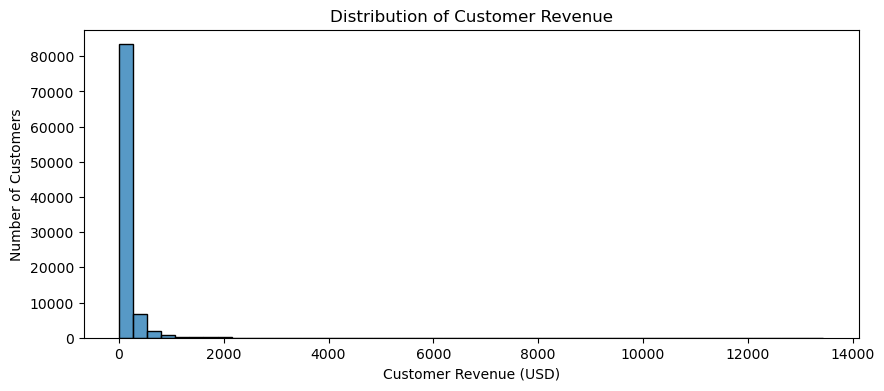

In [146]:
plt.figure(figsize=(10,4))

sns.histplot(
    customer_revenue["total_revenue"],
    bins=50
)

plt.title("Distribution of Customer Revenue")
plt.xlabel("Customer Revenue (USD)")
plt.ylabel("Number of Customers")

plt.show()

## Distribution of Customer Revenue

### Results

- Customer spending exhibits a highly right-skewed distribution.
- Most customers spend relatively small amounts.
- A small number of customers generate exceptionally high revenue.

### Findings

- Customer revenue is not evenly distributed across the customer base.
- High-value customers create a long right tail in the distribution.
- The majority of customers contribute modest revenue amounts.

### Key Insight

The marketplace relies on a relatively small group of high-spending customers who contribute disproportionately to overall revenue. This suggests opportunities for customer segmentation and targeted retention strategies.

### Second visualization that removes the extreme outliers so the typical customer behavior becomes visible.

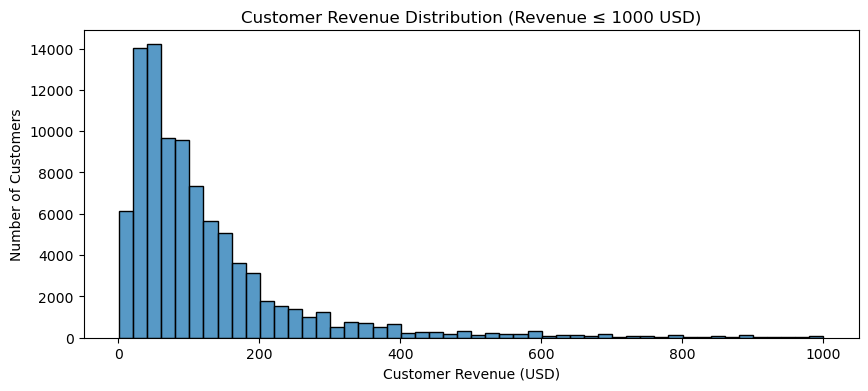

In [151]:
plt.figure(figsize=(10,4))

sns.histplot(
    customer_revenue[
        customer_revenue["total_revenue"] <= 1000
    ]["total_revenue"],
    bins=50
)

plt.title("Customer Revenue Distribution (Revenue ≤ 1000 USD)")
plt.xlabel("Customer Revenue (USD)")
plt.ylabel("Number of Customers")

plt.show()

## Customer Revenue Distribution (Revenue ≤ 1000 USD)

### Results

- Most customers generated less than 200 USD in revenue.
- Customer spending is concentrated between approximately 50 and 150 USD.
- The number of customers decreases as revenue increases.

### Findings

- The customer base is dominated by low-to-medium spending customers.
- High-spending customers represent a relatively small portion of the customer population.
- Revenue distribution remains right-skewed even after removing extreme outliers.

### Key Insight

The majority of customers generate modest revenue, while a small segment of higher-value customers contributes disproportionately to overall business performance.

## Next Analysis: Revenue Concentration Among Customers
What percentage of revenue comes from the top 10% of customers?

In [158]:
customer_revenue_sorted = customer_revenue.sort_values(
    "total_revenue",
    ascending=False
)

top_10_percent_count = int(len(customer_revenue_sorted) * 0.10)

top_10_percent_revenue = (
    customer_revenue_sorted
    .head(top_10_percent_count)["total_revenue"]
    .sum()
)

total_customer_revenue = (
    customer_revenue_sorted["total_revenue"]
    .sum()
)

top_10_percent_share = (
    top_10_percent_revenue /
    total_customer_revenue
) * 100

print(f"Top 10% Customer Revenue Share: {top_10_percent_share:.2f}%")

Top 10% Customer Revenue Share: 41.10%


## Revenue Concentration Among Customers

### Results

| Metric | Value |
|----------|----------:|
| Top 10% Customer Revenue Share | 41.10% |

### Findings

- The top 10% of customers generated 41.10% of total revenue.
- Revenue is concentrated among higher-value customers, but not excessively.
- A substantial portion of revenue is still generated by the remaining customer base.

### Key Insight

Customer revenue is moderately concentrated, with the highest-value customers contributing a significant share of total sales. However, the marketplace is not overly dependent on a small group of customers, indicating a relatively diversified revenue base.

## Next Step: Purchase Frequency.

In [162]:
customer_revenue["total_orders"].value_counts().sort_index()

total_orders
1     90557
2      2573
3       181
4        28
5         9
6         5
7         3
9         1
15        1
Name: count, dtype: int64

In [168]:
repeat_customers = (
    len(customer_revenue[customer_revenue["total_orders"] > 1])
    
)

total_customers = len(customer_revenue)

repeat_rate = (
    repeat_customers / total_customers
) * 100

print(f"Repeat Customer Rate: {repeat_rate:.2f}%")

Repeat Customer Rate: 3.00%


## Repeat Customer Analysis

### Results

| Metric | Value |
|----------|----------:|
| Repeat Customer Rate | 3.00% |

### Findings

- Approximately 97% of customers made only one purchase.
- Only 3% of customers returned to make additional purchases.
- Repeat purchasing behavior is relatively uncommon within the marketplace.

### Key Insight

Customer retention appears to be a significant opportunity for improvement. The vast majority of customers made a single purchase, suggesting that future growth may benefit from initiatives focused on increasing customer loyalty and repeat transactions.

## Customer Segmentation by Spending

I already have the quartiles:

- 25% = 47.65
- 50% = 89.73
- 75% = 154.74

In [175]:
customer_revenue["customer_segment"] = pd.cut(
    customer_revenue["total_revenue"],
    bins=[0, 47.65, 89.73, 154.74, float("inf")],
    labels=[
        "Low Value",
        "Medium Value",
        "High Value",
        "VIP"
    ]
)

customer_revenue["customer_segment"].value_counts()

customer_segment
Low Value       23341
VIP             23340
High Value      23339
Medium Value    23338
Name: count, dtype: int64

## Customer Segmentation by Spending

### Results

| Segment | Customers |
|----------|----------:|
| Low Value | 23,341 |
| Medium Value | 23,338 |
| High Value | 23,339 |
| VIP | 23,340 |

### Findings

- Customers were segmented using revenue quartiles.
- Each segment contains approximately 25% of the customer base.
- The segmentation provides a structured framework for comparing customer value levels.

### Key Insight

Revenue-based customer segmentation enables the identification of distinct customer groups and provides a foundation for targeted marketing, retention strategies, and customer value analysis.

In [178]:
segment_revenue = (
    customer_revenue
    .groupby("customer_segment", observed=False)["total_revenue"]
    .sum()
    .reset_index()
)

segment_revenue["revenue_share"] = (
    segment_revenue["total_revenue"] /
    segment_revenue["total_revenue"].sum()
) * 100

segment_revenue

,customer_segment,total_revenue,revenue_share
0,Low Value,679248.11,5.137452
1,Medium Value,1527015.44,11.549489
2,High Value,2747817.32,20.782950
3,VIP,8267417.24,62.530109


## Revenue Contribution by Customer Segment

### Results

| Segment | Revenue (USD) | Revenue Share |
|----------|------------:|------------:|
| Low Value | 679,248 | 5.14% |
| Medium Value | 1,527,015 | 11.55% |
| High Value | 2,747,817 | 20.78% |
| VIP | 8,267,417 | 62.53% |

### Findings

- Revenue contribution varies substantially across customer segments.
- VIP customers generate nearly two-thirds of total revenue.
- Low Value customers contribute only a small share of overall sales despite representing 25% of the customer base.

### Key Insight

Customer value is highly concentrated among the VIP segment. While VIP customers represent only 25% of customers, they generate 62.53% of total revenue, highlighting the importance of customer retention and value-based marketing strategies.

# Conclusion

This exploratory data analysis examined customer purchasing behavior, revenue performance, product category trends, geographic patterns, and customer value within the Olist e-commerce marketplace.

### Key Findings

- Monthly revenue grew from near zero in early periods to approximately 1 million USD per month, indicating significant business expansion.
- Revenue growth was primarily driven by increasing order volume rather than higher customer spending per order, as Average Order Value (AOV) remained relatively stable over time.
- The top 10 product categories generated 63.22% of total revenue, demonstrating a high concentration of sales among a limited number of categories.
- Revenue was geographically concentrated, with the top 3 states (SP, RJ, and MG) contributing 63.38% of total marketplace revenue.
- The top 10% of customers generated 41.10% of total revenue, highlighting the importance of high-value customers.
- Customer retention was relatively low, with only 3.00% of customers making more than one completed purchase.
- Customer value segmentation revealed that the VIP segment, representing only 25% of customers, generated 62.53% of total revenue.

### Business Insights

The analysis indicates that business growth was primarily driven by customer acquisition and increasing transaction volume. Revenue is concentrated across a small number of product categories, geographic regions, and high-value customers. Additionally, the low repeat customer rate suggests a significant opportunity to improve customer retention and lifetime value through targeted engagement and loyalty strategies.

### Next Steps

The findings from this notebook provide a strong foundation for customer segmentation and advanced customer analytics. The next stage of the project will focus on RFM (Recency, Frequency, Monetary) analysis to identify customer segments such as Champions, Loyal Customers, Potential Loyalists, At Risk, and Lost Customers.